# Preprocessing 

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.float_format", "{:,.0f}".format)

In [54]:
df = pd.read_csv("../data/top_movies_cleaned.csv")
df.head(3)

,id,Movie Name,Release Date,Production Budget (USD),Domestic Gross (USD),Worldwide Gross (USD),Domestic Box Office (USD),International Box Office (USD),Worldwide Box Office (USD),Est. Domestic DVD Sales (USD),...,Production Method,Creative Type,Production/Financing Companies,Production Countries,Languages,Domestic Releases,International Releases,Theater counts,Domestic Share Percentage,Movie URL
0,1,Star Wars Ep. VII: The Force Awakens,2015-12-16,533200000,936662225,2056046835,"936,662,225","1,119,384,610","2,056,046,835","39,601,100",...,"Animation,Live Action",Science Fiction,"Lucasfilm,Bad Robot",United States,English,"December 18th, 2015 (IMAX) byWalt DisneyDecemb...","December 16th, 2015 (Wide) (Belgium)December 1...","4,134 opening theaters/4,134 max. theaters, 9....",46,https://www.the-numbers.com/movie/Star-Wars-Ep...
1,2,Avatar: The Way of Water,2022-12-09,460000000,684075767,2315589775,"684,075,767","1,631,514,008","2,315,589,775","7,771,432",...,"Animation,Live Action",Science Fiction,"Lightstorm Entertainment,20th Century Studios,...",United States,English,"December 16th, 2022 (Wide) by20th Century Stud...","December 9th, 2022 (Wide) (Finland)December 14...","4,202 opening theaters/4,340 max. theaters, 11...",30,https://www.the-numbers.com/movie/Avatar-The-W...
2,3,Indiana Jones and the Dial of Destiny,2023-06-28,402300000,174480468,383963057,"174,480,468","209,482,589","383,963,057",NaN,...,Live Action,Historical Fiction,"Lucasfilm,Walt Disney Pictures,Paramount Pictures",United States,English,"June 30th, 2023 (Wide) byWalt DisneyJune 30th,...","June 28th, 2023 (Wide) (Australia)June 28th, 2...","4,600 opening theaters/4,600 max. theaters, 4....",45,https://www.the-numbers.com/movie/Indiana-Jone...


In [55]:
df.shape

(6569, 32)

In [56]:
df.columns.unique()

Index(['id', 'Movie Name', 'Release Date', 'Production Budget (USD)',
       'Domestic Gross (USD)', 'Worldwide Gross (USD)',
       'Domestic Box Office (USD)', 'International Box Office (USD)',
       'Worldwide Box Office (USD)', 'Est. Domestic DVD Sales (USD)',
       'Est. Domestic Blu-ray Sales (USD)',
       'Total Est. Domestic Video Sales (USD)', 'Opening Weekend (USD)',
       'Legs', 'Infl. Adj. Dom. BO (USD)', 'Video Release', 'MPAA Rating',
       'Running Time (minutes)', 'Franchise', 'Keywords', 'Source', 'Genre',
       'Production Method', 'Creative Type', 'Production/Financing Companies',
       'Production Countries', 'Languages', 'Domestic Releases',
       'International Releases', 'Theater counts', 'Domestic Share Percentage',
       'Movie URL'],
      dtype='str')

### Normalize column names

In [57]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.replace("/", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

df.columns

Index(['id', 'movie_name', 'release_date', 'production_budget_usd',
       'domestic_gross_usd', 'worldwide_gross_usd', 'domestic_box_office_usd',
       'international_box_office_usd', 'worldwide_box_office_usd',
       'est_domestic_dvd_sales_usd', 'est_domestic_blu_ray_sales_usd',
       'total_est_domestic_video_sales_usd', 'opening_weekend_usd', 'legs',
       'infl_adj_dom_bo_usd', 'video_release', 'mpaa_rating',
       'running_time_minutes', 'franchise', 'keywords', 'source', 'genre',
       'production_method', 'creative_type', 'production_financing_companies',
       'production_countries', 'languages', 'domestic_releases',
       'international_releases', 'theater_counts', 'domestic_share_percentage',
       'movie_url'],
      dtype='str')

### Basic missing-value overview

In [58]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100,
    "dtype": df.dtypes
}).sort_values("missing_percentage", ascending=False)

missing_summary.head(20)

,missing_count,missing_percentage,dtype
franchise,5146,78,str
est_domestic_blu_ray_sales_usd,4413,67,float64
est_domestic_dvd_sales_usd,4003,61,float64
total_est_domestic_video_sales_usd,3819,58,float64
international_releases,3338,51,str
production_financing_companies,2369,36,str
international_box_office_usd,1525,23,float64
worldwide_box_office_usd,1525,23,float64
video_release,1231,19,str
theater_counts,1175,18,str


In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6569 entries, 0 to 6568
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  6569 non-null   str    
 1   movie_name                          6569 non-null   str    
 2   release_date                        6420 non-null   str    
 3   production_budget_usd               6569 non-null   int64  
 4   domestic_gross_usd                  6569 non-null   int64  
 5   worldwide_gross_usd                 6569 non-null   int64  
 6   domestic_box_office_usd             5847 non-null   float64
 7   international_box_office_usd        5044 non-null   float64
 8   worldwide_box_office_usd            5044 non-null   float64
 9   est_domestic_dvd_sales_usd          2566 non-null   float64
 10  est_domestic_blu_ray_sales_usd      2156 non-null   float64
 11  total_est_domestic_video_sales_usd  2750 non-null   fl

### Convert Release Date to datetime 

In [60]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

df["release_year"] = df["release_date"].dt.year
df["release_month"] = df["release_date"].dt.month
df["release_quarter"] = df["release_date"].dt.quarter

df[["release_date", "release_year", "release_month", "release_quarter"]].head()

,release_date,release_year,release_month,release_quarter
0,2015-12-16,"2,015",12,4
1,2022-12-09,"2,022",12,4
2,2023-06-28,"2,023",6,2
3,2019-04-23,"2,019",4,2
4,2025-05-21,"2,025",5,2


### Extract theater-count variables from 'theater_counts'

In [61]:
df['theater_counts'][0]

'4,134 opening theaters/4,134 max. theaters, 9.2 weeks average run per theater'

In [62]:
df["opening_theaters"] = (
    df["theater_counts"]
    .astype(str)
    .str.extract(r"([\d,]+)\s+opening theaters")[0]
    .str.replace(",", "", regex=False)
)

df["max_theaters"] = (
    df["theater_counts"]
    .astype(str)
    .str.extract(r"([\d,]+)\s+max\. theaters")[0]
    .str.replace(",", "", regex=False)
)

df["avg_weeks_per_theater"] = (
    df["theater_counts"]
    .astype(str)
    .str.extract(r"([\d\.]+)\s+weeks average run per theater")[0]
)

df["opening_theaters"] = pd.to_numeric(df["opening_theaters"], errors="coerce")
df["max_theaters"] = pd.to_numeric(df["max_theaters"], errors="coerce")
df["avg_weeks_per_theater"] = pd.to_numeric(df["avg_weeks_per_theater"], errors="coerce")

df[["theater_counts", "opening_theaters", "max_theaters", "avg_weeks_per_theater"]].head()

,theater_counts,opening_theaters,max_theaters,avg_weeks_per_theater
0,"4,134 opening theaters/4,134 max. theaters, 9....","4,134","4,134",9
1,"4,202 opening theaters/4,340 max. theaters, 11...","4,202","4,340",11
2,"4,600 opening theaters/4,600 max. theaters, 4....","4,600","4,600",5
3,"4,662 opening theaters/4,662 max. theaters, 8....","4,662","4,662",8
4,NaN,NaN,NaN,NaN


### Assure numeric columns are indeed numeric

In [63]:
numeric_cols = [
    "production_budget_usd",
    "domestic_gross_usd",
    "worldwide_gross_usd",
    "domestic_box_office_usd",
    "international_box_office_usd",
    "worldwide_box_office_usd",
    "est_domestic_dvd_sales_usd",
    "est_domestic_blu_ray_sales_usd",
    "total_est_domestic_video_sales_usd",
    "opening_weekend_usd",
    "legs",
    "infl_adj_dom_bo_usd",
    "domestic_share_percentage",
    "running_time_minutes",
    "opening_theaters",
    "max_theaters",
    "avg_weeks_per_theater"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_cols]

,production_budget_usd,domestic_gross_usd,worldwide_gross_usd,domestic_box_office_usd,international_box_office_usd,worldwide_box_office_usd,est_domestic_dvd_sales_usd,est_domestic_blu_ray_sales_usd,total_est_domestic_video_sales_usd,opening_weekend_usd,legs,infl_adj_dom_bo_usd,domestic_share_percentage,running_time_minutes,opening_theaters,max_theaters,avg_weeks_per_theater
0,533200000,936662225,2056046835,"936,662,225","1,119,384,610","2,056,046,835","39,601,100","151,559,711","191,160,811","247,966,675",4,"1,191,447,782",46,136,"4,134","4,134",9
1,460000000,684075767,2315589775,"684,075,767","1,631,514,008","2,315,589,775","7,771,432","11,365,092","19,136,524","134,100,226",5,"693,596,368",30,190,"4,202","4,340",11
2,402300000,174480468,383963057,"174,480,468","209,482,589","383,963,057",NaN,NaN,NaN,"60,368,101",3,"174,480,468",45,142,"4,600","4,600",5
3,400000000,858373000,2748242781,"858,373,000","1,889,869,781","2,748,242,781","23,961,293","83,907,696","107,868,989","357,115,007",2,"1,010,181,328",31,181,"4,662","4,662",8
4,400000000,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6564,6000,48482,240495,"48,482","192,013","240,495",NaN,NaN,NaN,"1,636",8,"102,874",20,NaN,1,2,4
6565,5000,1338,1338,"1,338",NaN,NaN,NaN,NaN,NaN,357,4,"2,242",100,NaN,1,1,2
6566,1400,0,0,NaN,NaN,NaN,"24,343",NaN,"24,343",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6567,1100,181041,181041,"181,041",NaN,NaN,NaN,NaN,NaN,"85,222",2,"304,460",100,NaN,58,58,2


In [64]:
df["is_franchise"] = df["franchise"].notna().astype(int)

df["profit_worldwide"] = (
    df["worldwide_box_office_usd"] - df["production_budget_usd"]
)

df["profit_domestic"] = (
    df["domestic_box_office_usd"] - df["production_budget_usd"]
)

df["roi_worldwide"] = (
    df["worldwide_box_office_usd"] / df["production_budget_usd"]
)

df["roi_domestic"] = (
    df["domestic_box_office_usd"] / df["production_budget_usd"]
)
df.head(3)

,id,movie_name,release_date,production_budget_usd,domestic_gross_usd,worldwide_gross_usd,domestic_box_office_usd,international_box_office_usd,worldwide_box_office_usd,est_domestic_dvd_sales_usd,...,release_month,release_quarter,opening_theaters,max_theaters,avg_weeks_per_theater,is_franchise,profit_worldwide,profit_domestic,roi_worldwide,roi_domestic
0,1,Star Wars Ep. VII: The Force Awakens,2015-12-16,533200000,936662225,2056046835,"936,662,225","1,119,384,610","2,056,046,835","39,601,100",...,12,4,"4,134","4,134",9,1,"1,522,846,835","403,462,225",4,2
1,2,Avatar: The Way of Water,2022-12-09,460000000,684075767,2315589775,"684,075,767","1,631,514,008","2,315,589,775","7,771,432",...,12,4,"4,202","4,340",11,1,"1,855,589,775","224,075,767",5,1
2,3,Indiana Jones and the Dial of Destiny,2023-06-28,402300000,174480468,383963057,"174,480,468","209,482,589","383,963,057",NaN,...,6,2,"4,600","4,600",5,1,"-18,336,943","-227,819,532",1,0


### Create log-transformed variables

In [65]:
df["log_domestic_box_office"] = np.log1p(df["domestic_box_office_usd"])

df["log_worldwide_box_office"] = np.log1p(df["worldwide_box_office_usd"])

df["log_budget"] = np.log1p(df["production_budget_usd"])

df["log_opening_weekend"] = np.log1p(df["opening_weekend_usd"])

df["log_opening_theaters"] = np.log1p(df["opening_theaters"])

df["log_max_theaters"] = np.log1p(df["max_theaters"])

### Clean categorical columns

In [66]:
categorical_cols = [
    "mpaa_rating",
    "genre",
    "source",
    "production_method",
    "creative_type",
    "production_countries",
    "languages"
]

for col in categorical_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .replace(["nan", "None", ""], np.nan)
    )

In [67]:
print(df.columns.unique)
df.shape

<bound method Index.unique of Index(['id', 'movie_name', 'release_date', 'production_budget_usd',
       'domestic_gross_usd', 'worldwide_gross_usd', 'domestic_box_office_usd',
       'international_box_office_usd', 'worldwide_box_office_usd',
       'est_domestic_dvd_sales_usd', 'est_domestic_blu_ray_sales_usd',
       'total_est_domestic_video_sales_usd', 'opening_weekend_usd', 'legs',
       'infl_adj_dom_bo_usd', 'video_release', 'mpaa_rating',
       'running_time_minutes', 'franchise', 'keywords', 'source', 'genre',
       'production_method', 'creative_type', 'production_financing_companies',
       'production_countries', 'languages', 'domestic_releases',
       'international_releases', 'theater_counts', 'domestic_share_percentage',
       'movie_url', 'release_year', 'release_month', 'release_quarter',
       'opening_theaters', 'max_theaters', 'avg_weeks_per_theater',
       'is_franchise', 'profit_worldwide', 'profit_domestic', 'roi_worldwide',
       'roi_domestic', 'log_d

(6569, 49)

In [68]:
cols_to_drop = [
    "id",
    "movie_url",
    "video_release",
    "domestic_releases",
    "international_releases",
    "theater_counts",
    "production_financing_companies",
    "keywords",
    "languages",
    "production_countries"
]

df_reduced = df.drop(columns=cols_to_drop, errors="ignore")

df_reduced.shape

(6569, 39)

In [69]:
missing_summary = pd.DataFrame({
    "missing_count": df_reduced.isna().sum(),
    "missing_percentage": df_reduced.isna().mean() * 100,
    "dtype": df_reduced.dtypes
}).sort_values("missing_percentage", ascending=False)

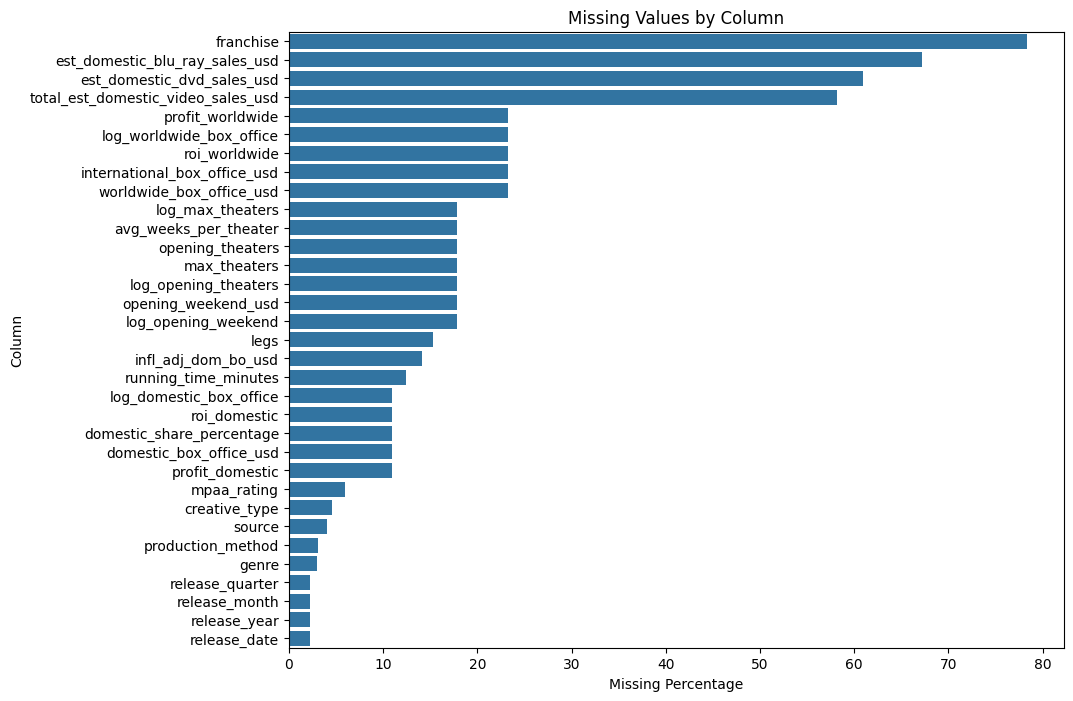

In [70]:
missing_summary_nonzero = missing_summary[missing_summary["missing_count"] > 0]

plt.figure(figsize=(10, 8))
sns.barplot(
    data=missing_summary_nonzero.reset_index(),
    x="missing_percentage",
    y="index"
)
plt.title("Missing Values by Column")
plt.xlabel("Missing Percentage")
plt.ylabel("Column")
plt.show()

### Drop rows that have nulls in essential columns for our analysis 

In [71]:
# Keep all columns, but drop rows missing the core variables needed for analysis

essential_cols = [
    "movie_name",
    "release_date",
    "release_year",
    "production_budget_usd",
    "domestic_box_office_usd",
    "worldwide_box_office_usd",
    "opening_weekend_usd",
    "max_theaters",
    "log_domestic_box_office",
    "log_worldwide_box_office",
    "log_budget",
    "log_max_theaters",
    "mpaa_rating",
    "genre"
]

df_reduced = df_reduced.dropna(subset=essential_cols).copy()

print("Shape after dropping rows missing essential variables:", df_reduced.shape)

display(
    df_reduced[essential_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

Shape after dropping rows missing essential variables: (4480, 39)


movie_name                  0
release_date                0
release_year                0
production_budget_usd       0
domestic_box_office_usd     0
worldwide_box_office_usd    0
opening_weekend_usd         0
max_theaters                0
log_domestic_box_office     0
log_worldwide_box_office    0
log_budget                  0
log_max_theaters            0
mpaa_rating                 0
genre                       0
dtype: int64

In [72]:
missing_summary = pd.DataFrame({
    "missing_count": df_reduced.isna().sum(),
    "missing_percentage": df_reduced.isna().mean() * 100,
    "dtype": df_reduced.dtypes
}).sort_values("missing_percentage", ascending=False)

missing_summary

,missing_count,missing_percentage,dtype
franchise,3295,74,str
est_domestic_blu_ray_sales_usd,2568,57,float64
est_domestic_dvd_sales_usd,2151,48,float64
total_est_domestic_video_sales_usd,2083,46,float64
running_time_minutes,258,6,float64
creative_type,28,1,str
source,16,0,str
infl_adj_dom_bo_usd,7,0,float64
production_method,2,0,str
max_theaters,0,0,float64


In [73]:
cols_to_drop_null_irrelevant = [
    "franchise",
    "est_domestic_blu_ray_sales_usd",
    "est_domestic_dvd_sales_usd",
    "total_est_domestic_video_sales_usd"
]

df_reduced = df_reduced.drop(columns=cols_to_drop_null_irrelevant, errors="ignore")

df_reduced.shape

(4480, 35)

In [74]:
missing_after_drop = pd.DataFrame({
    "missing_count": df_reduced.isna().sum(),
    "missing_percentage": df_reduced.isna().mean() * 100,
    "dtype": df_reduced.dtypes
}).sort_values("missing_percentage", ascending=False)

missing_after_drop[missing_after_drop["missing_count"] > 0]

,missing_count,missing_percentage,dtype
running_time_minutes,258,6,float64
creative_type,28,1,str
source,16,0,str
infl_adj_dom_bo_usd,7,0,float64
production_method,2,0,str


In [75]:
# Fill missing numeric values
df_reduced["running_time_minutes"] = df_reduced["running_time_minutes"].fillna(
    df_reduced["running_time_minutes"].median()
)

df_reduced["infl_adj_dom_bo_usd"] = df_reduced["infl_adj_dom_bo_usd"].fillna(
    df_reduced["infl_adj_dom_bo_usd"].median()
)

# Fill missing categorical values
categorical_missing_cols = [
    "creative_type",
    "source",
    "production_method"
]

for col in categorical_missing_cols:
    df_reduced[col] = df_reduced[col].fillna("Unknown")

In [76]:
missing_after_drop = pd.DataFrame({
    "missing_count": df_reduced.isna().sum(),
    "missing_percentage": df_reduced.isna().mean() * 100,
    "dtype": df_reduced.dtypes
}).sort_values("missing_percentage", ascending=False)

missing_after_drop

,missing_count,missing_percentage,dtype
movie_name,0,0,str
profit_domestic,0,0,float64
release_quarter,0,0,float64
opening_theaters,0,0,float64
max_theaters,0,0,float64
avg_weeks_per_theater,0,0,float64
is_franchise,0,0,int64
profit_worldwide,0,0,float64
roi_worldwide,0,0,float64
release_year,0,0,float64


In [77]:
df_reduced.head(2)

,movie_name,release_date,production_budget_usd,domestic_gross_usd,worldwide_gross_usd,domestic_box_office_usd,international_box_office_usd,worldwide_box_office_usd,opening_weekend_usd,legs,...,profit_worldwide,profit_domestic,roi_worldwide,roi_domestic,log_domestic_box_office,log_worldwide_box_office,log_budget,log_opening_weekend,log_opening_theaters,log_max_theaters
0,Star Wars Ep. VII: The Force Awakens,2015-12-16,533200000,936662225,2056046835,"936,662,225","1,119,384,610","2,056,046,835","247,966,675",4,...,"1,522,846,835","403,462,225",4,2,21,21,20,19,8,8
1,Avatar: The Way of Water,2022-12-09,460000000,684075767,2315589775,"684,075,767","1,631,514,008","2,315,589,775","134,100,226",5,...,"1,855,589,775","224,075,767",5,1,20,22,20,19,8,8


In [80]:
df_clean = df_reduced.copy()
df_clean.to_csv("../data/top_movies_cleaned_final.csv", index=False)

In [83]:
# create the EDA Analysis dataset

eda_cols = [
    "movie_name",
    "release_date",
    "release_year",
    "release_month",
    "release_quarter",

    "production_budget_usd",
    "domestic_box_office_usd",
    "international_box_office_usd",
    "worldwide_box_office_usd",
    "opening_weekend_usd",

    "opening_theaters",
    "max_theaters",
    "avg_weeks_per_theater",

    "mpaa_rating",
    "genre",
    "source",
    "production_method",
    "creative_type",

    "running_time_minutes",
    "domestic_share_percentage",
    "legs",
    "is_franchise",

    "log_domestic_box_office",
    "log_worldwide_box_office",
    "log_budget",
    "log_opening_weekend",
    "log_opening_theaters",
    "log_max_theaters"
]

eda_df = df_clean[eda_cols].copy()

eda_df.to_csv("../data/top_movies_cleaned_eda.csv", index=False)

In [85]:
# regression dataset
regression_cols = [
    "log_domestic_box_office",
    "log_worldwide_box_office",
    "log_max_theaters",
    "log_opening_theaters",
    "log_budget",
    "log_opening_weekend",

    "release_year",
    "release_month",
    "running_time_minutes",
    "is_franchise",

    "mpaa_rating",
    "genre",
    "source",
    "production_method",
    "creative_type"
]

reg_df = df_clean[regression_cols].copy()

reg_df.to_csv("../data/top_movies_cleaned_regression.csv", index=False)